In [6]:
import numpy as np
import pandas as pd

b0 = 10
b1 = 5
b2 = 3
b12 = 1

x1 = np.hstack([np.zeros(50), np.ones(50)])
x2 = np.hstack([np.zeros(25), np.ones(25)])
x2 = np.tile(x2, 2)

error = np.random.normal(0.0, 1.5, 100)

scale = b0 + b1 * x1 + b2 * x2 + b12 * x1 * x2 + error


durations = np.random.gamma(shape=2, scale=scale)
data = pd.DataFrame(np.vstack([x1, x2, durations]).T, columns=['f1', 'f2', 'duration'])

In [10]:
x2 = np.hstack([np.zeros(25), np.ones(25)])


In [14]:
data

,f1,f2,duration
0,0.0,0.0,1.199579
1,0.0,0.0,32.302690
2,0.0,0.0,10.323066
3,0.0,0.0,21.133490
4,0.0,0.0,4.463490
...,...,...,...
95,1.0,1.0,70.174831
96,1.0,1.0,42.804348
97,1.0,1.0,24.317330
98,1.0,1.0,74.375227


In [13]:
x2


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [15]:
import pymc3 as pm
import arviz as az


model = pm.Model()

with model:
    b0 = pm.Exponential('b0', lam=0.1)
    beta = pm.Normal('beta', mu=0, sd=10, shape=2)
    bi = pm.Normal('bi', mu=0, sd=10)

    scale = b0 + beta[0] * data['f1'] + beta[1] * data['f2']  + bi * data['f1'] * data['f2']
    rate = 1 / scale
    shape = pm.Exponential('shape', lam=0.1)

    duration = pm.Gamma('duration', alpha=shape, beta=rate, observed=data['duration'])
    trace = pm.sample(5000, chains=2, random_seed=42)

/var/folders/4_/vrr8kzqn5b9dxsprxn13022m0000gn/T/ipykernel_77159/3156662450.py:17: FutureWarning: In v4.0, pm.sample will return an `arviz.InferenceData` object instead of a `MultiTrace` by default. You can pass return_inferencedata=True or return_inferencedata=False to be safe and silence this warning.
  trace = pm.sample(5000, chains=2, random_seed=42)
Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 4 jobs)
NUTS: [shape, bi, beta, b0]


/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
/Users/kotarohara/repo/Python/web-optimization/venv/lib/python3.9/site-packages/scipy/stats/_continuous_distns.py:624: RuntimeWarning: overflow encountered in _beta_ppf
  return _boost._beta_ppf(q, a, b)
Sampling 2 chains for 1_000 tune and 5_000 draw iterations (2_000 + 10_000 draws total) took 8 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


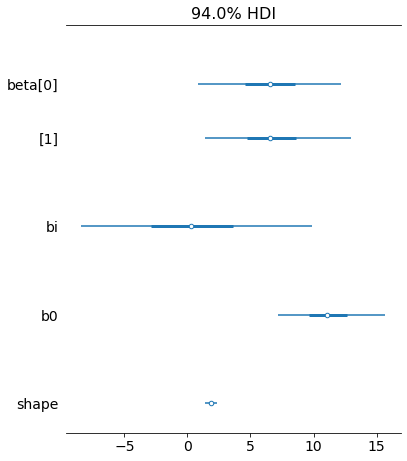

In [16]:
with model:
    az.plot_forest(trace, combined=True)